# Notebook 12 H2 - Analysis

## Hypothesis 2: 
References to feminist texts and thinkers in Heresies will show changing patterns of prominence over time, reflecting a move from foundational feminist works toward French feminist theory and later deconstruction-oriented influences.

### 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import ast
import numpy as np

### 2. Loading the person data

In [2]:
df_persons = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/07_h2_persons.csv")

print(df_persons.shape)
print(df_persons["volume"].value_counts())

(1315, 5)
volume
Vol1_1977-1978    295
Vol2_1978-1979    238
Vol3_1980-1981    209
Vol4_1981-1983    208
Vol5_1984-1985    172
Vol6_1987-1989    119
Vol7_1990-1993     74
Name: count, dtype: int64


### 3. Assigning the volume groups

In [3]:
def get_issue_number(filepath):
    match = re.search(r"heresies_(\d+)_combined", filepath)
    return int(match.group(1)) if match else None

def get_volume(issue_nr):
    if issue_nr <= 4:
        return "Vol1_1977-1978"
    elif issue_nr <= 8:
        return "Vol2_1978-1979"
    elif issue_nr <= 12:
        return "Vol3_1980-1981"
    elif issue_nr <= 16:
        return "Vol4_1981-1983"
    elif issue_nr <= 20:
        return "Vol5_1984-1985"
    elif issue_nr <= 24:
        return "Vol6_1987-1989"
    elif issue_nr <= 27:
        return "Vol7_1990-1993"
    else:
        return None

df_persons["issue"]  = df_persons["source_file"].apply(get_issue_number)
df_persons["volume"] = df_persons["issue"].apply(get_volume)

print(df_persons["volume"].value_counts())

volume
Vol1_1977-1978    295
Vol2_1978-1979    238
Vol3_1980-1981    209
Vol4_1981-1983    208
Vol5_1984-1985    172
Vol6_1987-1989    119
Vol7_1990-1993     74
Name: count, dtype: int64


#### 4. Person Frequency per volume

In [4]:
# count how often each person is mentioned per volume
freq = df_persons.groupby(["volume", "person"]).size().reset_index(name="count")
print(freq.head(20))

            volume                   person  count
0   Vol1_1977-1978     Abbe Jacques Boileau      1
1   Vol1_1977-1978             Ad Reinhardt      1
2   Vol1_1977-1978  Adelaide Alsop Robineau      1
3   Vol1_1977-1978            Adele Cambria      2
4   Vol1_1977-1978            Adele Raiffen      1
5   Vol1_1977-1978             Adolf Hitler      1
6   Vol1_1977-1978               Adolf Loos      4
7   Vol1_1977-1978      Adrian A. Gerbrands      1
8   Vol1_1977-1978             Agnes Martin      1
9   Vol1_1977-1978         Albert C. Barnes      1
10  Vol1_1977-1978           Albert Gleizes      2
11  Vol1_1977-1978            Aldous Huxley      1
12  Vol1_1977-1978            Alexa Freeman      1
13  Vol1_1977-1978               Alice Dick      1
14  Vol1_1977-1978              Alma Mahler      1
15  Vol1_1977-1978            Alma Routsong      1
16  Vol1_1977-1978               Amy Goldin      1
17  Vol1_1977-1978              Amy Sillman      1
18  Vol1_1977-1978          Amé

#### 5. Top referenced people overall

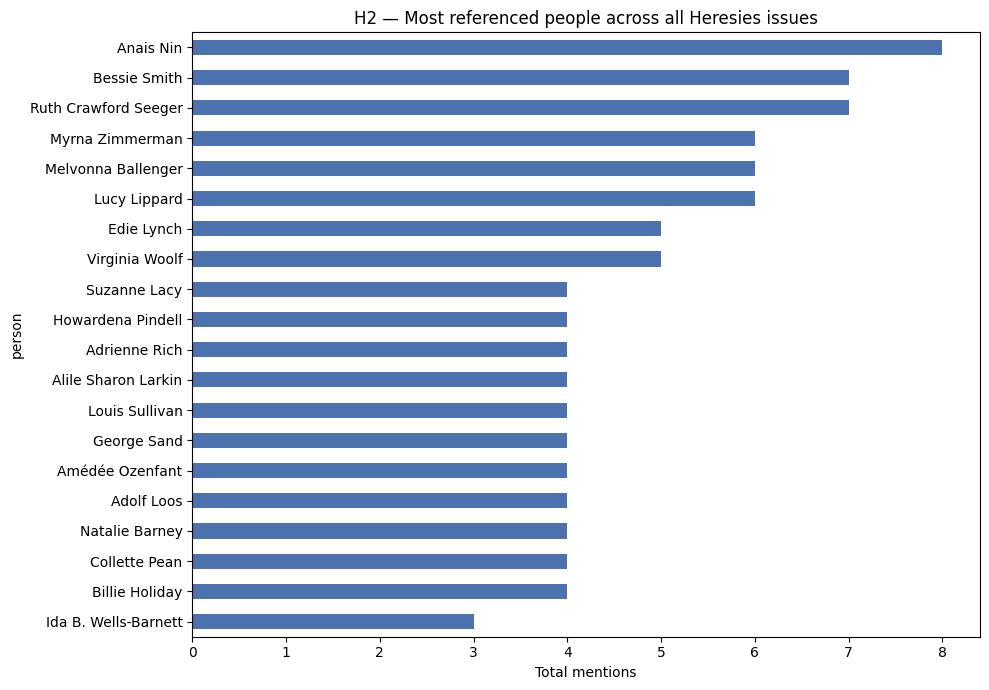

In [5]:
top_n = 20
top_persons = df_persons["person"].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
top_persons.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Total mentions")
ax.set_title("H2 — Most referenced people across all Heresies issues")
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h2_top_persons.png")
plt.show()

11 hits total confirms this: French feminist and deconstructionist thinkers are nearly absent from the corpus. Kristeva, Cixous, Irigaray, Derrida, Foucault — zero mentions across all 27 issues.
This is not a data problem anymore. You've checked the raw text, the NER output, and the tokens. They're genuinely not there.

This is actually a substantive finding for your thesis. H2 is not supported — and that's an interesting result. Heresies, at least in the issues you have, did not shift toward French feminist or deconstructionist theory. It remained anchored in Anglophone foundational feminism throughout.

What to do now:
Stop trying to force the grouped trend analysis — with 11 hits it will produce uninterpretable charts. Instead, reframe the analysis around what is there.
Two things worth doing instead:

Show who actually dominates the reference landscape — use your existing df_persons NER data to plot the top 15–20 most mentioned people across all issues. That's a legitimate H2 finding: these are the intellectual references Heresies actually drew on.
Document the absence explicitly — a small table showing zero or near-zero mentions of the expected French/deconstructionist names is itself evidence. You can present it as: the anticipated theoretical shift did not materialize in this journal.

#### 7. Thinker group search (raw text)


In [6]:
df_text = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/04_h2_clean.csv")
df_text["issue"] = df_text["source_file"].apply(get_issue_number)
print(df_text.shape)
print(df_text.columns.tolist())

(19703, 5)
['source_file', 'page_number', 'region_type', 'text', 'issue']


In [7]:
thinker_groups = {
    "Foundational":      ["Woolf", "de Beauvoir", "Millett", "Friedan", "Adrienne Rich", "Greer", "Wollstonecraft"],
    "French Feminist":   ["Cixous", "Irigaray", "Kristeva", "Wittig"],
    "Deconstructionist": ["Derrida", "Foucault", "Lacan", "Judith Butler", "Spivak", "Barthes"]
}

name_to_group = {name: group for group, names in thinker_groups.items() for name in names}

records = []
for _, row in df_text.iterrows():
    text   = row["text"] if isinstance(row["text"], str) else ""
    issue  = row["issue"]
    region = row["region_type"]
    for name, group in name_to_group.items():
        if re.search(re.escape(name), text, re.IGNORECASE):
            records.append({"issue": issue, "group": group, "name": name, "region_type": region})

df_hits = pd.DataFrame(records)
print(f"Total hits: {len(df_hits)}")
print(df_hits["name"].value_counts())

Total hits: 15
name
Woolf            5
Adrienne Rich    4
de Beauvoir      2
Wittig           2
Lacan            1
Derrida          1
Name: count, dtype: int64


#### 8. Absence table

In [8]:
expected = {
    "Foundational":      ["Woolf", "de Beauvoir", "Millett", "Friedan", "Adrienne Rich", "Greer"],
    "French Feminist":   ["Cixous", "Irigaray", "Kristeva", "Wittig"],
    "Deconstructionist": ["Derrida", "Foucault", "Lacan", "Barthes", "Judith Butler", "Spivak"]
}

rows = []
for group, names in expected.items():
    for name in names:
        count = df_hits[df_hits["name"] == name].shape[0] if not df_hits.empty else 0
        rows.append({"Group": group, "Name": name, "Mentions": count})

absence_table = pd.DataFrame(rows).sort_values(["Group", "Mentions"], ascending=[True, False])
print(absence_table.to_string(index=False))
absence_table.to_csv("/Users/sophiehamann/master-thesis-code/data/output_files/13_h2_absence_table.csv", index=False)

            Group          Name  Mentions
Deconstructionist       Derrida         1
Deconstructionist         Lacan         1
Deconstructionist      Foucault         0
Deconstructionist       Barthes         0
Deconstructionist Judith Butler         0
Deconstructionist        Spivak         0
     Foundational         Woolf         5
     Foundational Adrienne Rich         4
     Foundational   de Beauvoir         2
     Foundational       Millett         0
     Foundational       Friedan         0
     Foundational         Greer         0
  French Feminist        Wittig         2
  French Feminist        Cixous         0
  French Feminist      Irigaray         0
  French Feminist      Kristeva         0


The absence table gives you something concrete to put in the thesis — a clean presentation of what you looked for and what you found. That's more honest and more interesting than a flat chart with almost no data in it.

#### 9. Conceptual keyword trends across volumes

In [9]:
keyword_groups = {
    "Foundational": [
        "woman", "women", "equality", "oppression", "consciousness",
        "experience", "sisterhood", "patriarchy"
    ],
    "French Feminist": [
        "body", "desire", "pleasure", "difference", "sexuality",
        "feminine", "essentialism"
    ],
    "Deconstructionist": [
        "discourse", "power", "construction", "representation",
        "subjectivity", "identity", "deconstruction", "language"
    ]
}

# load full raw text with volume labels
df_raw = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/08_h2_lemmatized.csv")
df_raw["issue"]  = df_raw["source_file"].apply(get_issue_number)
df_raw["volume"] = df_raw["issue"].apply(get_volume)

vol_order = [
    "Vol1_1977-1978", "Vol2_1978-1979", "Vol3_1980-1981", "Vol4_1981-1983",
    "Vol5_1984-1985", "Vol6_1987-1989", "Vol7_1990-1993"
]

# count how many rows each volume has (for normalisation)
vol_totals = df_raw.groupby("volume").size()

# count keyword hits per volume
all_keywords = [kw for kws in keyword_groups.values() for kw in kws]
counts = {}

for kw in all_keywords:
    counts[kw] = {}
    for vol in vol_order:
        vol_texts = df_raw[df_raw["volume"] == vol]["text"].fillna("")
        hits = vol_texts.str.contains(r"\b" + kw + r"\b", case=False, regex=True).sum()
        counts[kw][vol] = round((hits / vol_totals[vol]) * 1000, 1)

# build dataframe
df_kw = pd.DataFrame(counts).T  # keywords as rows, volumes as columns
df_kw = df_kw[vol_order]        # make sure columns are in chronological order

print(df_kw)

                Vol1_1977-1978  Vol2_1978-1979  Vol3_1980-1981  \
woman                     27.1            14.0            16.2   
women                     85.2            65.4            77.9   
equality                   0.8             0.5             0.0   
oppression                 0.8             0.7             0.6   
consciousness              2.5             1.4             1.7   
experience                 3.1             4.2             6.1   
sisterhood                 0.3             0.2             0.3   
patriarchy                 1.1             0.5             0.3   
body                       4.0             4.4             1.7   
desire                     1.1             2.3             2.0   
pleasure                   0.6             0.0             1.4   
difference                 0.8             0.9             0.3   
sexuality                  0.8             0.9             7.5   
feminine                   1.1             0.7             1.2   
essentiali

In [1]:
# import matplotlib.pyplot as plt
# import numpy as np

# # put keywords in group order for the heatmap
# kw_order = [kw for kws in keyword_groups.values() for kw in kws]
# df_plot = df_kw.reindex(kw_order)

# # short volume labels for x axis
# short_vols = [v[:4] for v in vol_order]

# fig, ax = plt.subplots(figsize=(12, 8))
# im = ax.imshow(df_plot.values.astype(float), aspect="auto", cmap="YlOrRd")

# # axis labels
# ax.set_xticks(range(len(vol_order)))
# ax.set_xticklabels(short_vols, fontsize=10)
# ax.set_yticks(range(len(kw_order)))
# ax.set_yticklabels(kw_order, fontsize=10)

# # draw lines between groups
# group_sizes = [len(kws) for kws in keyword_groups.values()]
# divider = group_sizes[0] - 0.5
# ax.axhline(divider, color="white", linewidth=2)
# ax.axhline(divider + group_sizes[1], color="white", linewidth=2)

# plt.colorbar(im, ax=ax, label="Mentions per 1000 rows")
# ax.set_title("H2 — Conceptual keyword frequency across volumes")
# plt.tight_layout()
# plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h2_keyword_heatmap.png", dpi=150)
# plt.show()

Now I want to aggregate these keyword groups into three time series lines and sum up all the keyword scores per group per volume. 

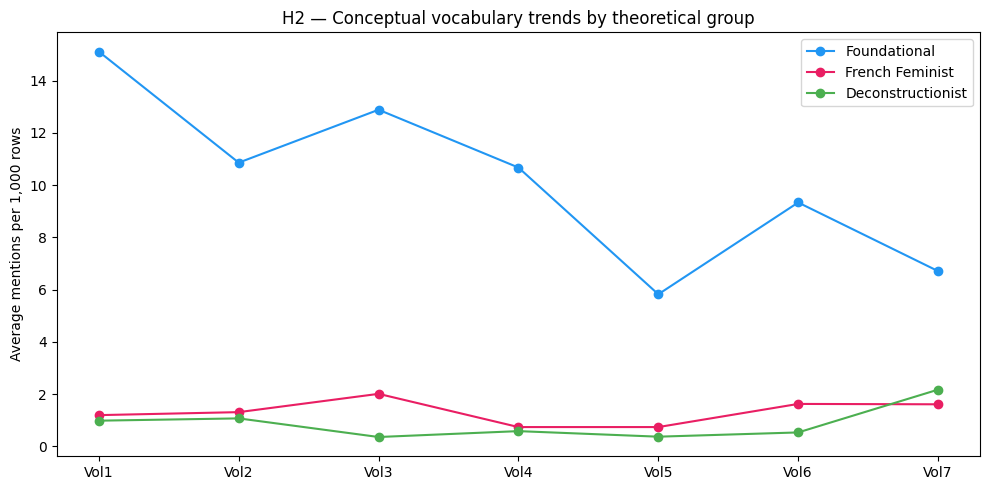

In [11]:


foundational_keywords = ["woman", "women", "equality", "oppression", "consciousness", "experience", "sisterhood", "patriarchy"]
french_keywords = ["body", "desire", "pleasure", "difference", "sexuality", "feminine", "essentialism"]
decon_keywords = ["discourse", "power", "construction", "representation", "subjectivity", "identity", "deconstruction", "language"]

# Here I need to calculate the average score per group per volume
foundational_avg = df_kw.loc[foundational_keywords].mean()
french_avg       = df_kw.loc[french_keywords].mean()
decon_avg        = df_kw.loc[decon_keywords].mean()

# Now plotting the three lines. 
short_vols = ["Vol1", "Vol2", "Vol3", "Vol4", "Vol5", "Vol6", "Vol7"]
x = range(len(short_vols))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, foundational_avg, marker="o", label="Foundational",      color="#2196F3")
ax.plot(x, french_avg,       marker="o", label="French Feminist",   color="#E91E63")
ax.plot(x, decon_avg,        marker="o", label="Deconstructionist", color="#4CAF50")

ax.set_xticks(x)
ax.set_xticklabels(short_vols)
ax.set_ylabel("Average mentions per 1,000 rows")
ax.set_title("H2 — Conceptual vocabulary trends by theoretical group")
ax.legend()
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h2_group_trends.png", dpi=150)
plt.show()

#### 9. Saving results

In [12]:
freq.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/10_h2_person_frequency.csv", index=False)
absence_table.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/10_h2_absence_table.csv", index=False)